In [1]:
# Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
sns.set_style('whitegrid')

In [ ]:
# Import preprocessing and visualization functions
import sys
sys.path.append('/content/drive/My Drive/Personal Project/')  # adjust path if needed
from preprocessing import (
    preprocess_gdsc_data,
    plot_missing_values,
    plot_numeric_histograms,
    plot_numeric_boxplots,
    plot_categorical_frequencies
)

# Set base path
base = "/content/drive/My Drive/Cancer Pharmacogenomics/GDSC Dataset/"
filepath = base + "GDSC_DATASET.csv"

In [ ]:
# Call preprocessing function
(X_train_processed, X_test_processed, y_train, y_test,
 preprocessor, feature_names, X_train_raw, X_test_raw) = preprocess_gdsc_data(filepath)

print("Preprocessing completed.")
print(f"Processed training shape: {X_train_processed.shape}")
print(f"Processed test shape: {X_test_processed.shape}")

Preprocessing completed.
Processed training shape: (193628, 1615)
Processed test shape: (48407, 1615)


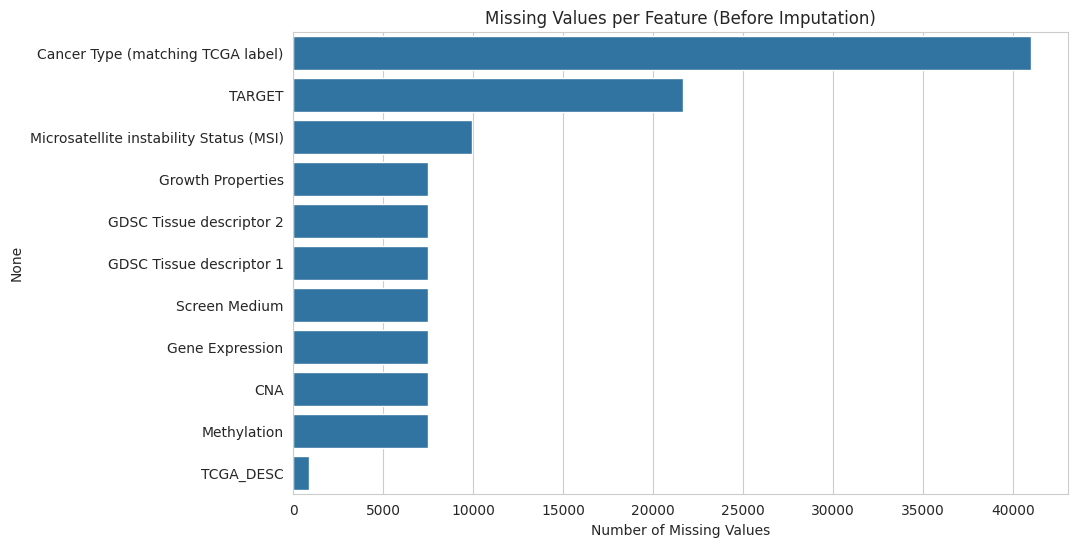

In [ ]:
# Visualize missing values
plot_missing_values(X_train_raw)

In [ ]:
# Identify numeric and categorical features for plotting
numeric_features = X_train_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_features = X_train_raw.select_dtypes(include=['object', 'category']).columns.tolist()

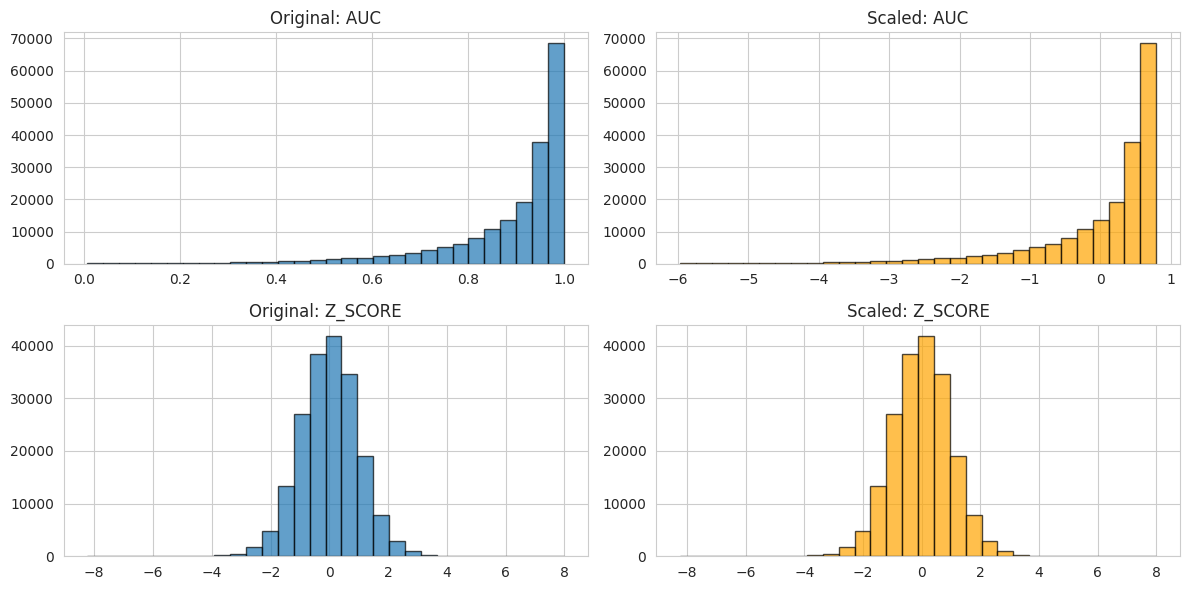

In [ ]:
# Histograms of numeric features
plot_numeric_histograms(X_train_raw, X_train_processed, numeric_features)

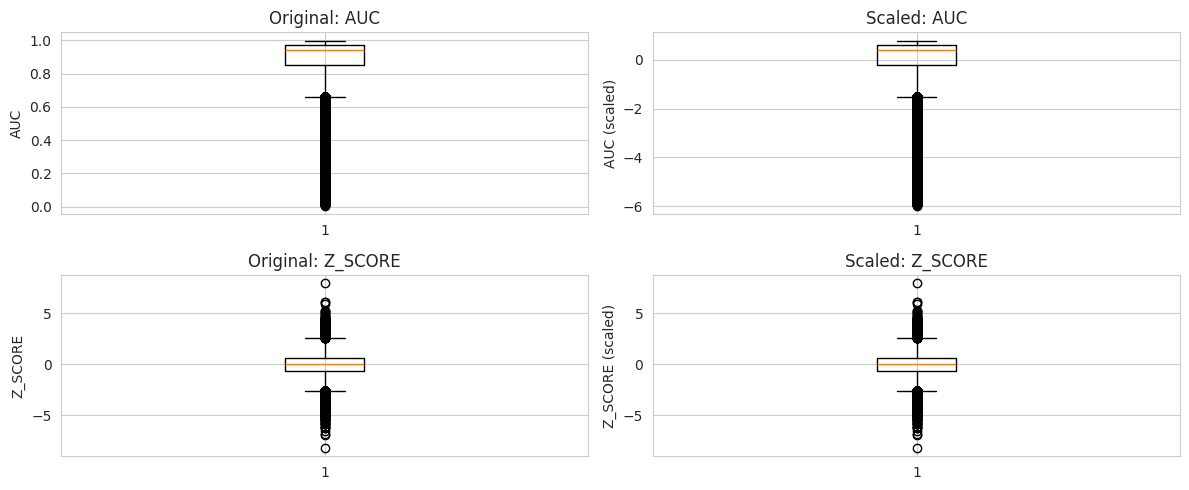

In [ ]:
# Boxplots of numeric features
plot_numeric_boxplots(X_train_raw, X_train_processed, numeric_features)

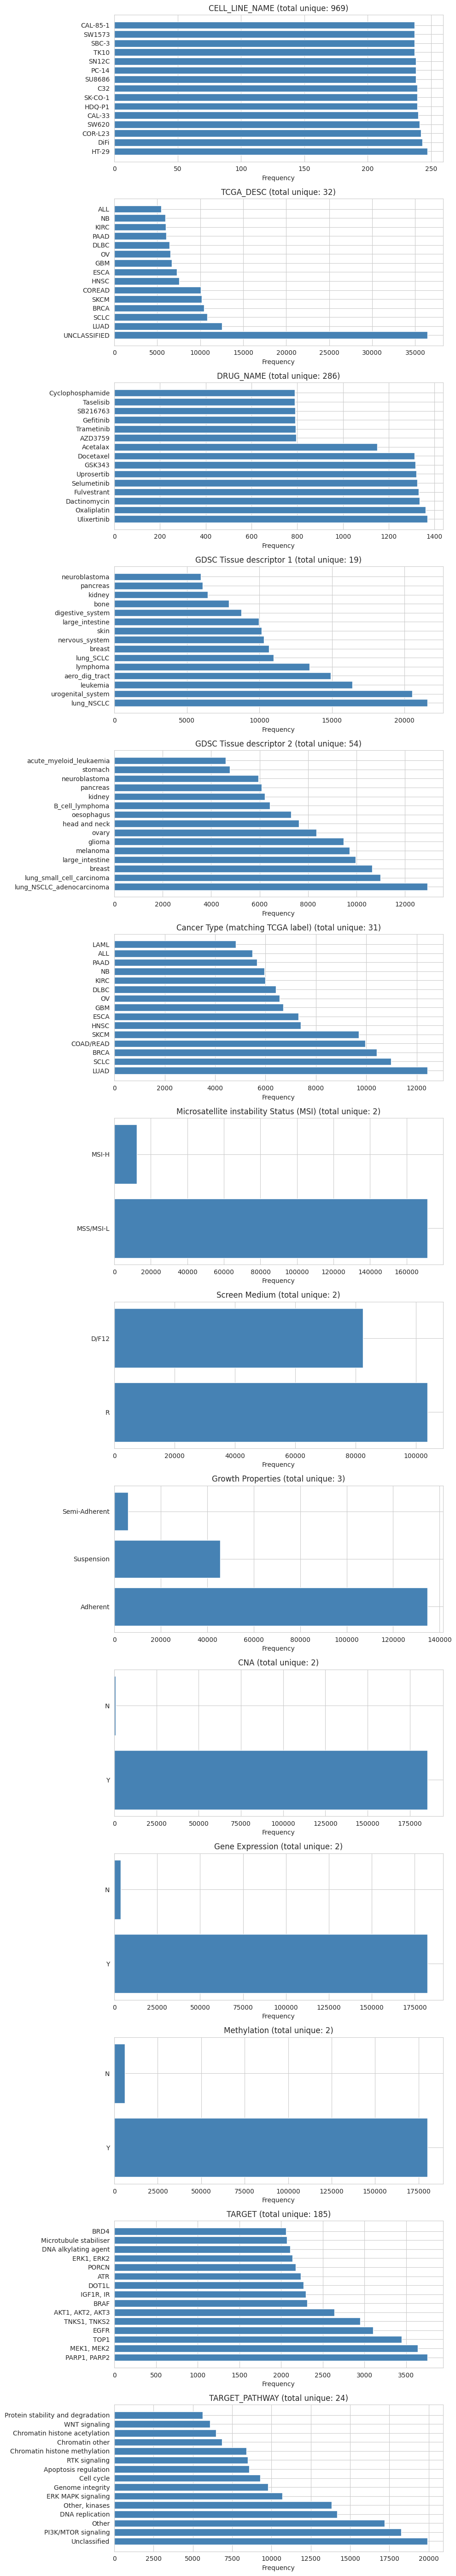


Categorical feature cardinalities:
CELL_LINE_NAME: 969 unique values
TCGA_DESC: 32 unique values
DRUG_NAME: 286 unique values
GDSC Tissue descriptor 1: 19 unique values
GDSC Tissue descriptor 2: 54 unique values
Cancer Type (matching TCGA label): 31 unique values
Microsatellite instability Status (MSI): 2 unique values
Screen Medium: 2 unique values
Growth Properties: 3 unique values
CNA: 2 unique values
Gene Expression: 2 unique values
Methylation: 2 unique values
TARGET: 185 unique values
TARGET_PATHWAY: 24 unique values


In [ ]:
# Categorical feature frequencies
plot_categorical_frequencies(X_train_raw, categorical_features)

In [ ]:
print("Preprocessing Summary:")
print(f"Original feature count (after dropping identifiers): {X_train_raw.shape[1]}")
print(f"Numeric features scaled to zero mean and unit variance.")
print(f"Categorical features one-hot encoded (unknown categories handled).")
print(f"Data split: {X_train_raw.shape[0]} training samples, {X_test_raw.shape[0]} test samples.")
print(f"Processed feature dimension: {X_train_processed.shape[1]}")

Preprocessing Summary:
Original feature count (after dropping identifiers): 16
Numeric features scaled to zero mean and unit variance.
Categorical features one-hot encoded (unknown categories handled).
Data split: 193628 training samples, 48407 test samples.
Processed feature dimension: 1615
